In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import duckdb
import dill

warnings.filterwarnings("ignore")

PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "config.py").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR, RAW_DIR
from src.analysis.metrics import EVENT_COLS
from src.analysis.passing.passing import PASS_ANALYSIS_COLS
from src.analysis.possession.possession import build_possession_summary
from src.analysis.possession.compare import (
    build_event_style_table,
    build_possession_style_table,
    longest_possessions,
    regular_play_start_zones,
    top_turnover_types,
)
from src.analysis.possession.viz import (
    plot_entry_rates,
    plot_possession_duration_by_team,
    plot_possession_progression_scatter,
    plot_possession_start_end_heatmaps,
    plot_pressure_directness_scatter,
    plot_team_metric_comparison,
    plot_pass_height_comparison,
    plot_pass_count_distribution,
)
from src.analysis.possession.rhythm import (
    build_possession_rhythm,
    build_intra_possession_tempo,
    build_rhythm_summary,
    summarize_rhythm_by_team,
)
from src.analysis.possession.viz import (
    plot_tempo_distribution,
    plot_rhythm_consistency,
    plot_intra_possession_tempo_profile,
    plot_circulation_vs_progression,
    plot_progression_efficiency,
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

MATCH_ID = 3749493
TEAMS = ["Arsenal", "Everton"]

# dill.load_session('../saves/notebook_env.db')

In [2]:
events_path = PROCESSED_DIR / "events_2004.parquet"
match_cols = sorted(set(EVENT_COLS + PASS_ANALYSIS_COLS))
match_df = pd.read_parquet(events_path, columns=match_cols)
match_df = match_df[match_df["match_id"] == MATCH_ID].copy()

match_info = (
    pd.read_csv(PROCESSED_DIR / "matches_2004.csv")
    .loc[lambda d: d["match_id"] == MATCH_ID]
    .iloc[0]
)
print(
    f"{match_info['match_home_team']} {match_info['match_score']} "
    f"{match_info['match_away_team']} — {match_info['match_kickoff']}"
)
print(f"Events: {len(match_df):,}")


Arsenal 2 - 1 Everton — 2003-08-16 13:00:00.000
Events: 3,057


<hr>

## Arsenal vs Everton

Arsenal went unbeaten in 2003/04; this was their opening fixture (`match_id` 3749493). We compare possession-chain structure and event-level passing between the two sides.

## Possession analysis

We want to see whether the possession was structured vs. chaotic using metrics, such as `duration`, `event_count`, `pass_count`. This helps us understand:

1. How long can the team sustain control?
2. Are possession deliberate or rushed?
3. Does the team recycle possession or attack immediately?

This should provide insight to whether or not the early 2000s premier league fit the stereotype that it had shorter possession, fewer actions, more transitions and quicker vertical attacks. Some other questions to consider:

- How efficiently does the team move upfield?
- Is progression gradual or explosive?
- Does buildup happen through controlled advancement?
- Can the team maintain possession under pressure?
- How does pressure affect possession length?
- Does the team break pressure structurally?
- Which possessions create danger?
- Are dangerous possessions long or short?
- Does the team create chances through structure or transition?


In [3]:
possession_summary = build_possession_summary(match_df)
possession_summary.to_csv(PROCESSED_DIR / "possession_summary.csv", index=False)

duckdb.register("possession_summary", possession_summary)
print(f"Possession chains: {len(possession_summary):,}")

Possession chains: 201


<hr>

## Variables

The progression metrics that I gathered, detailed in the columns are:

### Identity
- `match_id`: StatsBomb match id
- `period`: Match period: 1 first half, 2 second half, etc.
- `possession_id`: StatsBomb possession chain id within the match
- `possession_team`: Team that controls the possession chain
- `play_pattern`: How the possession started, e.g. Regular Play, From Throw In, From Corner
- `opponent`: The opposing team in the match

### Time / Control
- `start_minute`: Minute of the first event in the possession
- `start_second`: Second of the first event in the possession
- `end_minute`: Minute of the final event in the possession
- `end_second`: Second of the final event in the possession
- `start_time`: Possession start time in seconds from period clock, calculated as minute * 60 + second
- `end_time`: Possession end time in seconds from period clock, calculated as minute * 60 + second
- `clock_duration`: Elapsed clock time of the possession in seconds
- `action_duration`: Sum of StatsBomb event duration values within the possession
- `avg_event_duration`: Average event duration within the possession
- `event_count`: Total number of events in the possession chain
- `pass_count`: Number of Pass events by the possession team
- `carry_count`: Number of Carry events by the possession team
- `touch_count`: pass_count + carry_count; rough proxy for controlled ball actions

### Tempo / Deliberateness
- `events_per_second`: Event density, calculated as event_count divided by clock_duration
- `passes_per_second`: Pass tempo, calculated as pass_count divided by clock_duration
- `directness_ratio`: Net x progression divided by total pass/carry distance. Near 1 means direct forward play, near 0 means recycling, and negative means backward movement

### Progression
- `start_x`: X coordinate of the possession team’s first on-ball location
- `start_y`: Y coordinate of the possession team’s first on-ball location
- `end_x`: X coordinate of the possession team’s final on-ball/end location
- `end_y`: Y coordinate of the possession team’s final on-ball/end location
- `net_x_progression`: end_x - start_x; how far upfield the possession ended relative to where it began
- `total_x_progression`: Sum of all positive x movement from possession-team passes and carries
- `progressive_distance`: Sum of large positive x movements, currently movements with x gain >= 10
- `max_x_reached`: Furthest x coordinate reached during the possession
- `final_third_entry`: True if the possession reached x >= 80
- `box_entry`: True if the possession reached the box area, defined as x >= 102 and 18 <= y <= 62

### Pressure
- `pressure_event_count`: Number of explicit opponent Pressure events during the possession
- `under_pressure_count`: Number of possession-team events marked under_pressure
- `pressure_rate`: under_pressure_count divided by possession-team event count
- `pressured_pass_count`: Number of possession-team passes made under pressure
- `pressured_pass_completion`: Completion rate of possession-team passes made under pressure
- `counterpress_faced`: Number of opponent events marked counterpress during the possession

### Outcome / Danger
- `shot_count`: Number of shots by the possession team in the possession
- `xg_created`: Sum of shot_statsbomb_xg from possession-team shots
- `key_pass_count`: Number of shot assists or goal assists in the possession
- `turnover_type`: Label inferred from the final possession-team event, e.g. Pass - Incomplete, Shot - Saved, Out
- `ends_with_shot`: True if the final possession-team event was a shot
- `ends_in_final_third`: True if the possession team’s final location was in the final third
- `ends_in_box`: True if the possession team’s final location was in the box


<hr>

## Analysis & Visuals

### Possession Comparisons

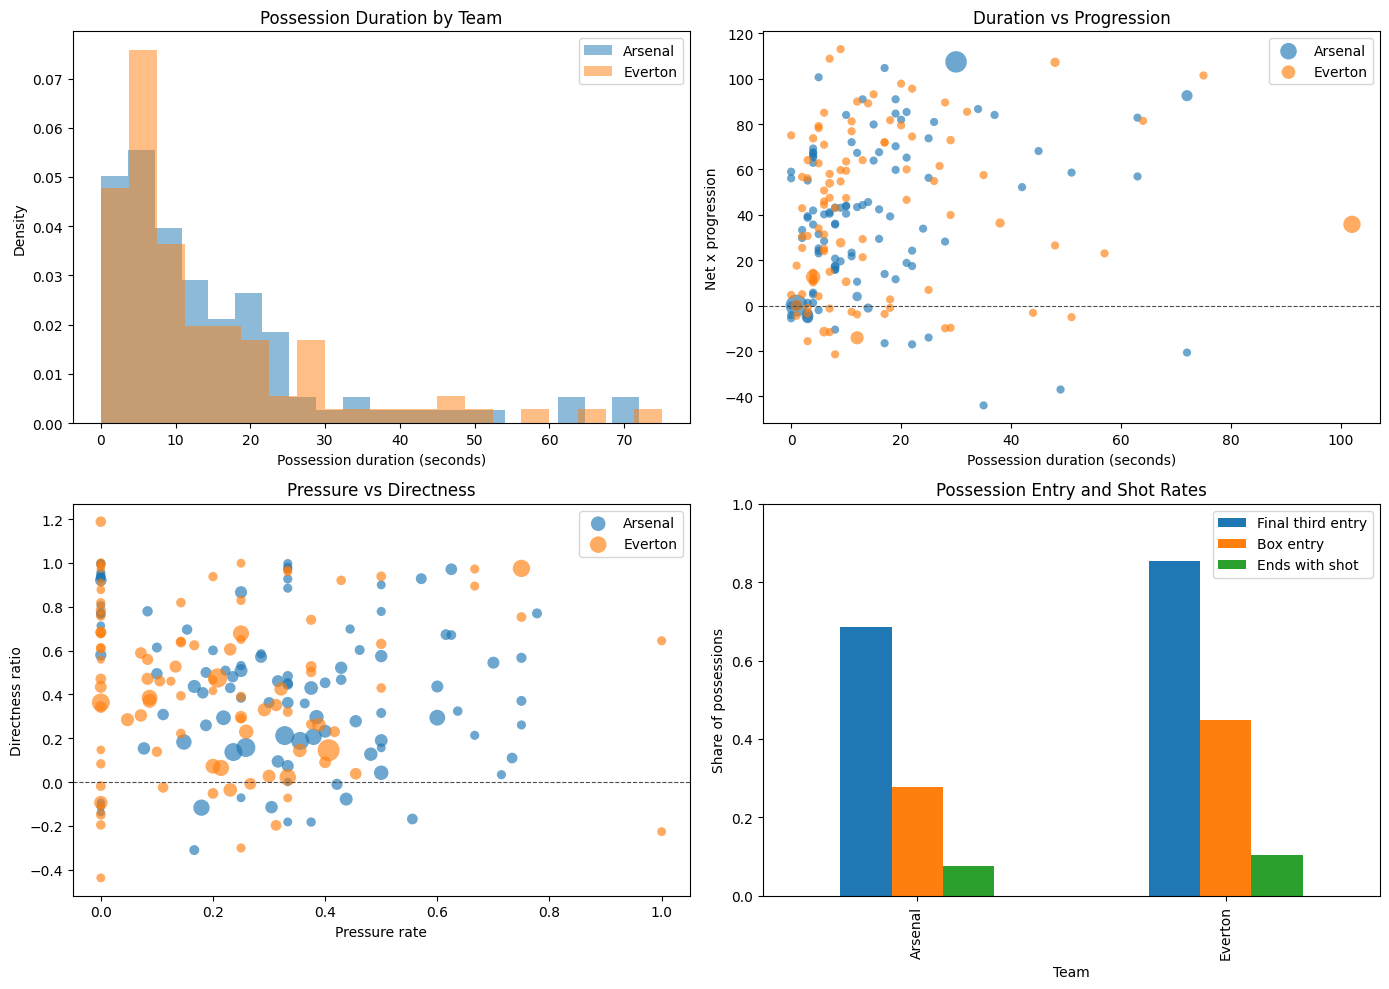

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_possession_duration_by_team(possession_summary, ax=axes[0, 0])
plot_possession_progression_scatter(possession_summary, ax=axes[0, 1])
plot_pressure_directness_scatter(possession_summary, ax=axes[1, 0])
plot_entry_rates(possession_summary, ax=axes[1, 1])

plt.tight_layout()
plt.show()

In [5]:
danger_cols = [
    "possession_team",
    "possession_id",
    "clock_duration",
    "pass_count",
    "net_x_progression",
    "directness_ratio",
    "pressure_rate",
    "xg_created",
    "box_entry",
    "turnover_type",
]

possession_summary.sort_values(
    ["xg_created", "box_entry", "net_x_progression"],
    ascending=[False, True, True],
)[danger_cols]

,possession_team,possession_id,clock_duration,pass_count,net_x_progression,directness_ratio,pressure_rate,xg_created,box_entry,turnover_type
73,Arsenal,74,1,0,0.0,NaN,0.000000,0.783500,True,Shot - Goal
131,Arsenal,131,30,6,107.4,0.428936,0.375000,0.747578,True,Shot - Goal
15,Everton,16,102,9,35.8,0.145135,0.406250,0.440552,True,Foul Won
158,Everton,158,4,1,12.6,-0.301131,0.250000,0.266854,True,Shot - Off T
181,Everton,181,12,6,-14.2,-0.197794,0.312500,0.200138,True,Shot - Goal
...,...,...,...,...,...,...,...,...,...,...
2,Arsenal,3,34,12,86.6,0.296346,0.384615,0.000000,True,Miscontrol
72,Arsenal,73,19,6,90.9,0.571011,0.285714,0.000000,True,Dribble - Incomplete
187,Everton,187,22,4,95.6,0.605244,0.230769,0.000000,True,Foul Committed
122,Everton,122,20,6,97.8,0.526779,0.133333,0.000000,True,Pass - Incomplete


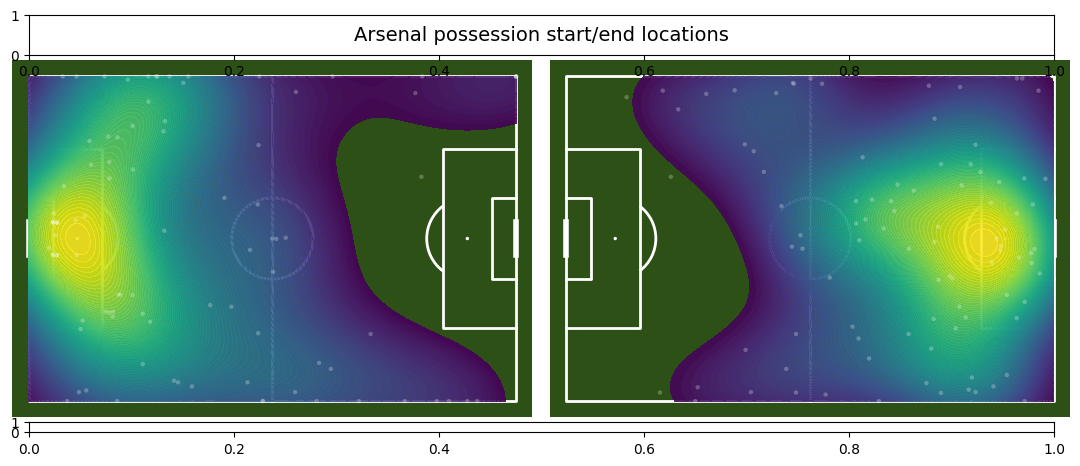

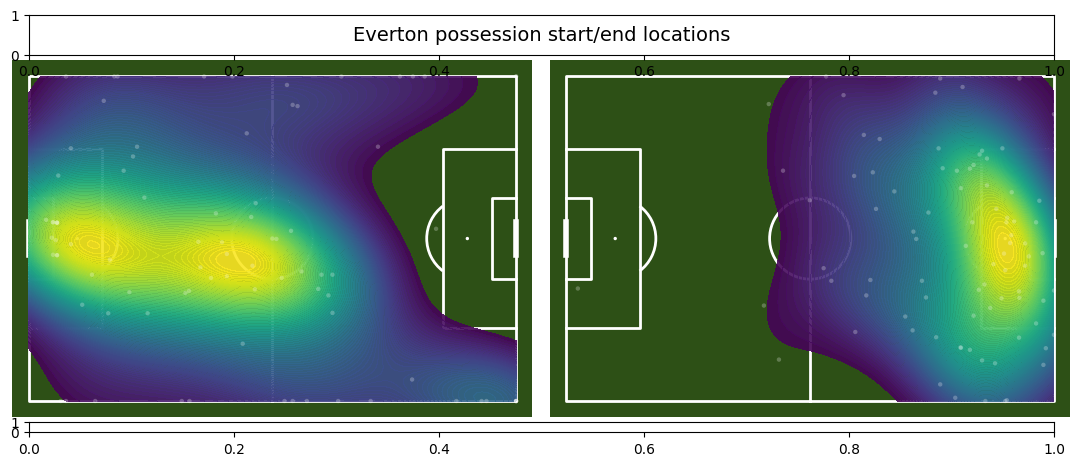

In [6]:
from IPython.display import display

for team in possession_summary["possession_team"].dropna().unique():

    fig = plot_possession_start_end_heatmaps(
        possession_summary,
        team=team,
        min_duration=3,
    )

    # display(fig)
    plt.show()

**Pitch thirds** (StatsBomb x): defensive x < 40, midfield 40–80, attacking ≥ 80.


In [7]:
from IPython.display import display

TEAMS = ["Arsenal", "Everton"]

event_style = build_event_style_table(match_df, TEAMS)
possession_style = build_possession_style_table(possession_summary, TEAMS)
possession_style.to_csv(PROCESSED_DIR / "possession_style.csv", index=False)
event_style.to_csv(PROCESSED_DIR / "event_style.csv", index=False)

print("=== Event-level passing & physicality ===")
display(event_style.round(2))

=== Event-level passing & physicality ===


,team,events,passes,pass_completion_pct,avg_pass_length_m,long_pass_pct,crosses,through_balls,passes_into_final_third,pressure_on_pass_pct,...,high_pass_pct,carries,dribbles,dribbles_complete,counterpresses,duels,fouls_committed,shots,xg,goals
0,Arsenal,1584.0,422.0,77.01,23.57,24.41,7.0,0.0,127.0,28.44,...,22.27,342.0,29.0,13.0,37.0,28.0,11.0,14.0,2.12,2.0
1,Everton,1473.0,381.0,66.40,28.06,38.85,19.0,3.0,188.0,18.11,...,41.73,235.0,7.0,5.0,78.0,55.0,19.0,15.0,1.27,1.0


The stylistic divide between the two sides is clear from the event-level numbers. Arsenal's average pass length of 23.57m — with only 24.41% of their passes classified as long — points to a team that prioritises short combinations and controlled buildup over the ball. Everton's average of 28.06m, with 38.85% of passes in the long category, reflects a more direct approach: bypassing the midfield press and looking to land the ball in behind for runners to attack.

This is reinforced by the attacking intent metrics. Everton's higher cross and through-ball counts suggest they sought to exploit wide areas and the channel between the lines rather than unpicking the defence through midfield progression. Arsenal, by contrast, leaned on carries and dribbles to advance the ball — indicators of a team comfortable holding possession and probing for gaps rather than committing to early vertical balls.

What makes the comparison striking is the outcome. Despite taking fundamentally different routes — Arsenal's patient, ground-based buildup versus Everton's more direct, aerial approach — both sides generated a similar volume of shots and comparable xG. Arsenal's efficiency ultimately proved the difference, as they converted their chances to win 2-1. It is an early illustration of a tension that runs through the 2003/04 season: Wenger's Invincibles were not just stylistically distinct, they were clinical enough to make that style pay.

In [ ]:
display(
    possession_style.round(2).pivot(
        index="scenario", columns="team", values="median_passes"
    )
)
display(possession_style.round(2))

team,Arsenal,Everton
scenario,,
All possessions,3.0,3.0
Regular Play,4.0,4.0
Regular Play (4+ passes),5.5,6.0
Regular Play (6+ passes),7.5,7.0


,scenario,team,possessions,median_events,median_passes,median_duration_sec,median_events_per_sec,median_directness,mean_directness,median_net_x,...,box_entry_pct,ends_final_third_pct,ends_box_pct,pressure_rate_pct,pressured_pass_completion_pct,ends_with_shot_pct,poss_with_shot_pct,total_xg,mean_start_x,mean_end_x
0,All possessions,Arsenal,105.0,12.0,3.0,10.0,1.25,0.45,0.44,39.0,...,27.62,57.14,22.86,30.09,73.43,7.62,10.48,2.12,43.92,81.23
1,All possessions,Everton,96.0,9.5,3.0,9.0,1.08,0.45,0.43,43.0,...,44.79,77.08,32.29,21.13,70.33,10.42,13.54,1.27,52.22,93.51
2,Regular Play,Arsenal,38.0,16.0,4.0,11.5,1.35,0.45,0.40,36.1,...,23.68,42.11,18.42,35.52,79.42,5.26,5.26,0.13,29.81,69.48
3,Regular Play,Everton,32.0,16.0,4.0,13.0,1.00,0.46,0.40,54.7,...,37.50,56.25,21.88,26.72,83.33,3.12,6.25,0.45,41.40,87.64
4,Regular Play (4+ passes),Arsenal,20.0,21.0,5.5,20.0,1.26,0.45,0.38,60.1,...,40.00,55.00,30.00,31.04,80.98,5.00,5.00,0.11,31.31,83.24
5,Regular Play (4+ passes),Everton,19.0,19.0,6.0,20.0,1.00,0.33,0.33,61.5,...,52.63,73.68,26.32,19.54,76.19,5.26,10.53,0.45,36.60,92.94
6,Regular Play (6+ passes),Arsenal,10.0,28.5,7.5,23.5,1.11,0.20,0.25,60.1,...,40.00,50.00,20.00,29.47,86.00,10.00,10.00,0.11,34.15,82.99
7,Regular Play (6+ passes),Everton,11.0,27.0,7.0,29.0,0.86,0.33,0.32,72.9,...,63.64,90.91,36.36,19.98,74.07,9.09,18.18,0.45,31.80,97.57


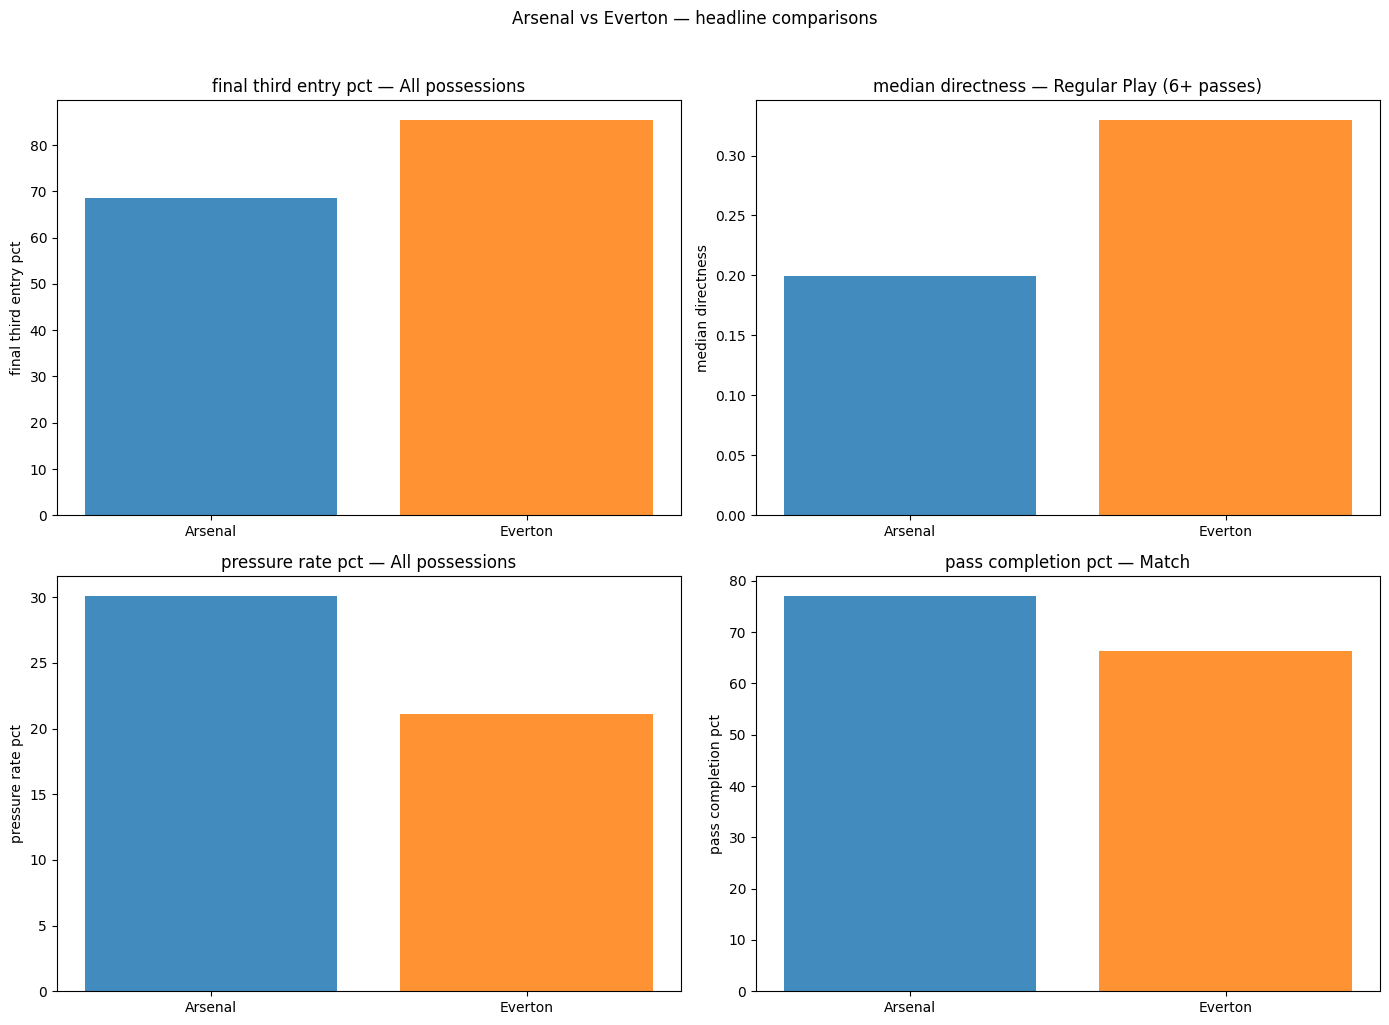

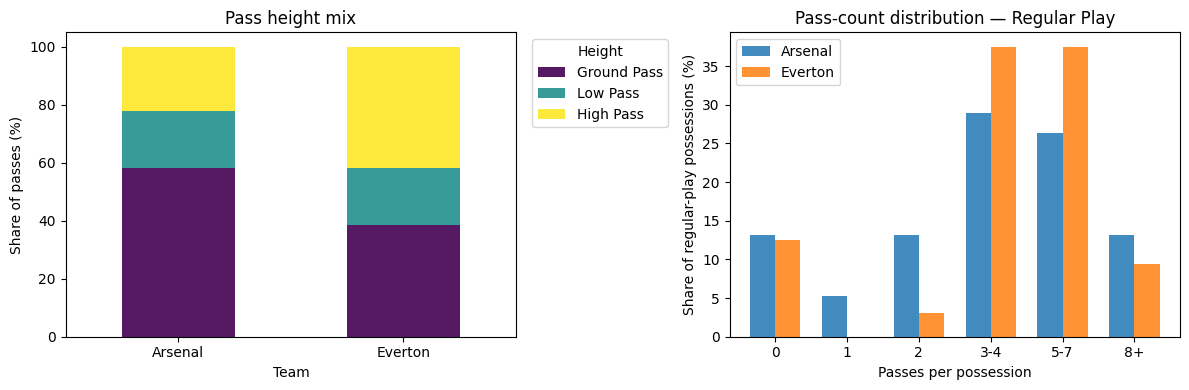

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_team_metric_comparison(
    possession_style, "final_third_entry_pct",
    scenario="All possessions", ax=axes[0, 0],
)
plot_team_metric_comparison(
    possession_style, "median_directness",
    scenario="Regular Play (6+ passes)", ax=axes[0, 1],
)
plot_team_metric_comparison(
    possession_style, "pressure_rate_pct",
    scenario="All possessions", ax=axes[1, 0],
)
event_plot = event_style.copy()
event_plot["scenario"] = "Match"
plot_team_metric_comparison(
    event_plot, "pass_completion_pct",
    scenario="Match", ax=axes[1, 1],
)

fig.suptitle("Arsenal vs Everton — headline comparisons", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pass_height_comparison(match_df, TEAMS, ax=axes[0])
plot_pass_count_distribution(possession_summary, TEAMS, ax=axes[1])
plt.tight_layout()
plt.show()


The charts reinforce what the headline numbers already suggested. Arsenal's pass height distribution is dominated by ground passes, reflecting a team that keeps the ball low and moves it through feet rather than going aerial. This is consistent with the short-passing, buildup-oriented profile established earlier — teams that play the ball on the ground tend to prioritise control and connection over territory gained in a single action.

The pass-count distribution adds another dimension: Arsenal's possessions are spread across a narrower and more predictable range, suggesting they sustain their buildup structure consistently rather than alternating between very short and very long chains. This even distribution is a hallmark of a team playing to a clear system — possessions rarely die after one or two touches, and they rarely need 15 passes to achieve what six can do.

Together, the two charts paint a picture of deliberate, structured possession: low to the ground, built in consistent phases, and rarely relying on the long ball to break lines.

### Possession outcomes

In [13]:
for team in TEAMS:
    zones = regular_play_start_zones(possession_summary, team)
    total = zones["count"].sum()
    print(f"\n{team} ({total} chains):")
    for _, row in zones.iterrows():
        pct = row["count"] / total * 100
        print(f"  {row['start_zone']:10s}: {row['count']:3d} ({pct:.0f}%)")

for team in TEAMS:
    print(f"\n{team}:")
    print(top_turnover_types(possession_summary, team).to_string())



Arsenal (37 chains):
  defensive :  30 (81%)
  midfield  :   6 (16%)
  attacking :   1 (3%)

Everton (31 chains):
  midfield  :  18 (58%)
  defensive :  13 (42%)

Arsenal:
turnover_type
Ball Receipt*           26
Foul Won                12
Pass - Incomplete       12
Miscontrol              10
Dribble - Incomplete    10
Dispossessed             8
Shot - Off T             6
Pressure                 6

Everton:
turnover_type
Ball Receipt*        29
Pass - Incomplete    17
Foul Won              8
Pass - Out            6
Dispossessed          5
Duel                  4
Pressure              4
Foul Committed        4


### Longest Possession

In [14]:
for team in TEAMS:
    print(f"\n{team}:")
    display(longest_possessions(possession_summary, team))



Arsenal:


,possession_id,play_pattern,pass_count,event_count,clock_duration,directness_ratio,net_x_progression,final_third_entry,xg_created
78,79,Regular Play,21,78,72,0.211871,92.5,True,0.106324
46,47,Regular Play,20,82,72,0.157343,-20.7,True,0.000000
81,82,From Free Kick,17,68,63,0.136809,56.9,True,0.000000
1,2,From Kick Off,15,51,49,-0.117140,-37.0,True,0.000000
138,138,Regular Play,15,62,63,0.187699,82.8,True,0.000000



Everton:


,possession_id,play_pattern,pass_count,event_count,clock_duration,directness_ratio,net_x_progression,final_third_entry,xg_created
143,143,From Throw In,16,53,48,0.064286,26.5,True,0.000000
114,114,From Goal Kick,11,34,44,0.385506,-3.2,True,0.000000
71,72,Regular Play,10,29,22,0.303621,74.5,True,0.000000
137,137,From Throw In,10,38,29,0.144186,39.9,True,0.000000
15,16,Regular Play,9,49,102,0.145135,35.8,True,0.440552


This backs our statement that Arsenal tends to prefer build up plays, having most of their possession being around a minute long compared to Everton's whose possession is comparatively low.

<hr>

### Possession Takeaways

**Arsenal (Wenger)**
- Regular-play chains overwhelmingly start in the **defensive third** — build-from-the-back.
- **Shorter, ground-based passing** (higher completion, fewer long balls and crosses).
- More **carries and dribbles**; slightly longer/faster chains on average.
- On 6+ pass Regular Play chains: **lower directness** — more recycling than vertical play.
- **More pressure faced**, but better completion under pressure; **higher xG** overall.

**Everton (Moyes)**
- More **midfield-started** open play — transitional, less deep buildup.
- **Longer, more aerial** passing; more crosses and final-third passes.
- **Higher territorial rates** (final-third/box entry) but **lower xG efficiency**.
- On 6+ pass chains: longer, more box entries, more shot-ending possessions.
- **Heavier counterpress and duel volume**; turnovers from **incomplete passes**.

This one match perfectly captures the shift from the "rushed" playstyle of Barclays PL to a more tactical, methodical and slow build up play, mainly influeced by the likes of Arsene Wenger and Jose Mourinho.


<hr>

## Rhythm

Rhythm captures *how* each possession unfolds in time — the speed between consecutive actions, how metronomic or variable that speed is, and the structural split between circulating the ball and committing to a progressive move forward.

Questions this section answers:

- **How fast does each team play?** — median inter-event gap per possession
- **How consistent is the tempo?** — coefficient of variation of gaps (lower = more metronomic)
- **Does tempo change as the possession develops?** — gap profile by event position within the chain
- **How long does the team circulate before progressing?** — passes and seconds before the first action with a large x-gain
- **How efficient is progression once it starts?** — passes per 10 m of territory gained

In [25]:
from src.analysis.possession.rhythm import (
    build_possession_rhythm,
    build_intra_possession_tempo,
    build_rhythm_summary,
    summarize_rhythm_by_team,
)
from src.analysis.possession.viz import (
    plot_tempo_distribution,
    plot_rhythm_consistency,
    plot_intra_possession_tempo_profile,
    plot_circulation_vs_progression,
    plot_progression_efficiency,
)

rhythm_summary = build_rhythm_summary(match_df, possession_summary, TEAMS)
intra_tempo = build_intra_possession_tempo(match_df, TEAMS)

rhythm_summary.to_csv(PROCESSED_DIR / "rhythm_summary.csv", index=False)

print(f"Rhythm chains (Regular Play): {len(rhythm_summary)}")
print(f"  Arsenal : {(rhythm_summary['possession_team'] == 'Arsenal').sum()}")
print(f"  Everton : {(rhythm_summary['possession_team'] == 'Everton').sum()}")

Rhythm chains (Regular Play): 70
  Arsenal : 38
  Everton : 32


<hr>

## Variables

- `median_gap_sec` : Typical pause between own-team actions — lower = faster-paced 
- `median_gap_cv` : How variable the tempo is within a possession — lower = metronomic
- `pct_consistent` : Share of possessions where CV < 1 (relatively even rhythm)
- `mean_burst_share` : Share of consecutive actions close in time — high = lots of rapid exchanges
- `pct_speeding_up` : Share of possessions where tempo accelerates as the chain develops
- `median_pre_prog_passes` : Passes before the first significant forward move (≥ 10 m x-gain)
- `median_pre_prog_duration_sec` : Seconds spent circulating before first progression
- `median_pre_prog_pass_share` : Fraction of total passes that happen before the first progression
- `median_passes_per_10m` : Passes needed to gain each 10 m of territory — lower = more direct

<hr>

In [26]:
rhythm_team = summarize_rhythm_by_team(rhythm_summary)

headline_cols = [
    "team",
    "possessions",
    "median_gap_sec",
    "median_gap_cv",
    "pct_consistent",
    "mean_burst_share",
    "pct_speeding_up",
    "median_pre_prog_passes",
    "median_pre_prog_duration_sec",
    "median_pre_prog_pass_share",
    "median_passes_per_10m",
]

display(rhythm_team[headline_cols].round(2))

,team,possessions,median_gap_sec,median_gap_cv,pct_consistent,mean_burst_share,pct_speeding_up,median_pre_prog_passes,median_pre_prog_duration_sec,median_pre_prog_pass_share,median_passes_per_10m
0,Arsenal,38,1.0,1.17,13.51,71.49,24.32,0.0,2.0,0.00,0.85
1,Everton,32,1.0,1.03,35.48,66.22,41.94,0.0,2.0,7.14,0.83


### Tempo speed and consistency

The violin shows the full distribution of per-possession median gap across all Regular Play chains. The scatter adds a second dimension: each point is one possession plotted as (gap speed, gap CV). Points in the bottom-left are fast *and* metronomic; bottom-right are fast but erratic; top-left are slow but structured.

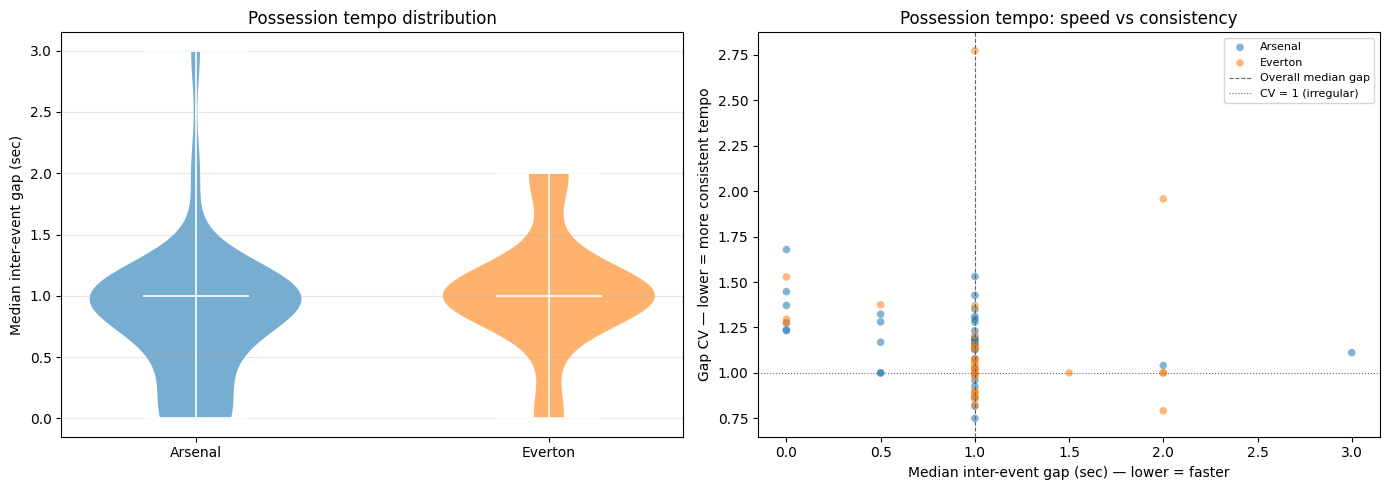

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_tempo_distribution(rhythm_summary, TEAMS, ax=axes[0])
plot_rhythm_consistency(rhythm_summary, TEAMS, ax=axes[1])

plt.tight_layout()
plt.show()

Tempo distribution (left)

Arsenal's possession tempo is notably more varied — their inter-event gap distribution spans a wider range, reflecting a style that mixes rapid short-passing sequences with deliberate pauses to control the ball and wait for structure. This variation is intentional rather than erratic: Arsenal shifts between gears within the same possession. Everton, by contrast, settle into a narrower band of medium-tempo play, preferring to carry the ball into space rather than recycling quickly through short passes — a rhythm that is more uniform but less adaptable.

Speed vs. consistency (right)

The scatter reinforces this contrast. Arsenal cluster toward the faster end of the speed axis but spread widely on the consistency axis, confirming that their quicker possessions come with deliberate tempo changes rather than a fixed pulse. Everton sit in the mid-speed range with tighter clustering along the consistency axis — their possessions tend to unfold at a predictable, even pace regardless of the situation. In short, Arsenal play fast but varied; Everton play steady but constrained.

### Tempo profile through the possession chain

Each point on the x-axis is an event position (1 = gap between own-team events 1 and 2, 2 = gap between 2 and 3, etc.). The y-axis is the median gap in seconds across all Regular Play possessions that reached that position.

A rising line means the team tends to slow down as the possession develops. A falling line means they speed up — typical of a team that starts controlled and then accelerates toward goal. A flat line is a metronomic, even tempo throughout.

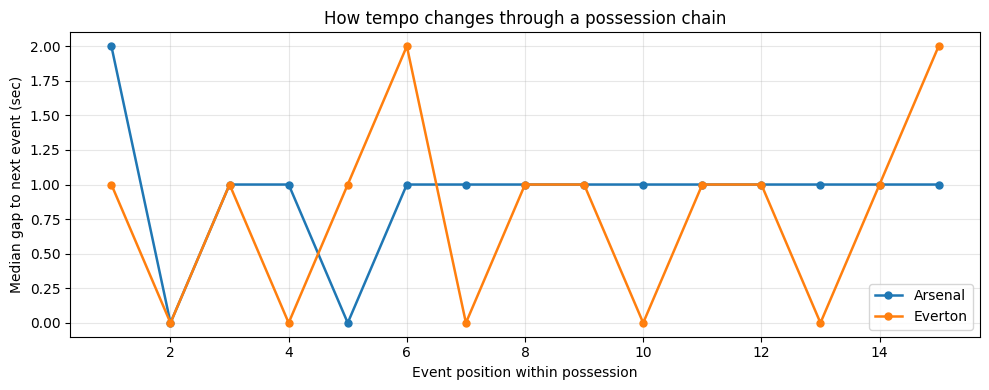


Tempo trend summary (positive = speeds up through possession):


,mean_trend,pct_speeding_up,median_trend
possession_team,,,
Arsenal,-1.121,25.714,-1.235
Everton,-0.326,46.429,-0.175


In [28]:
fig, ax = plt.subplots(figsize=(10, 4))
plot_intra_possession_tempo_profile(intra_tempo, TEAMS, max_position=15, ax=ax)
plt.tight_layout()
plt.show()

# Summary: are possessions speeding up or slowing down?
trend_summary = (
    rhythm_summary.dropna(subset=["tempo_trend"])
    .groupby("possession_team")["tempo_trend"]
    .agg(
        mean_trend="mean",
        pct_speeding_up=lambda x: (x > 0).mean() * 100,
        median_trend="median",
    )
    .round(3)
)
print("\nTempo trend summary (positive = speeds up through possession):")
display(trend_summary)

### Circulation before progression

How many passes does each team play before committing to a significant forward move (≥ 10 m x-gain)?

The scatter plots total passes against pre-progression passes. Points on the diagonal line mean the whole possession was circulation — the team never took a big forward step. Points well below the line mean they progressed early and kept moving.

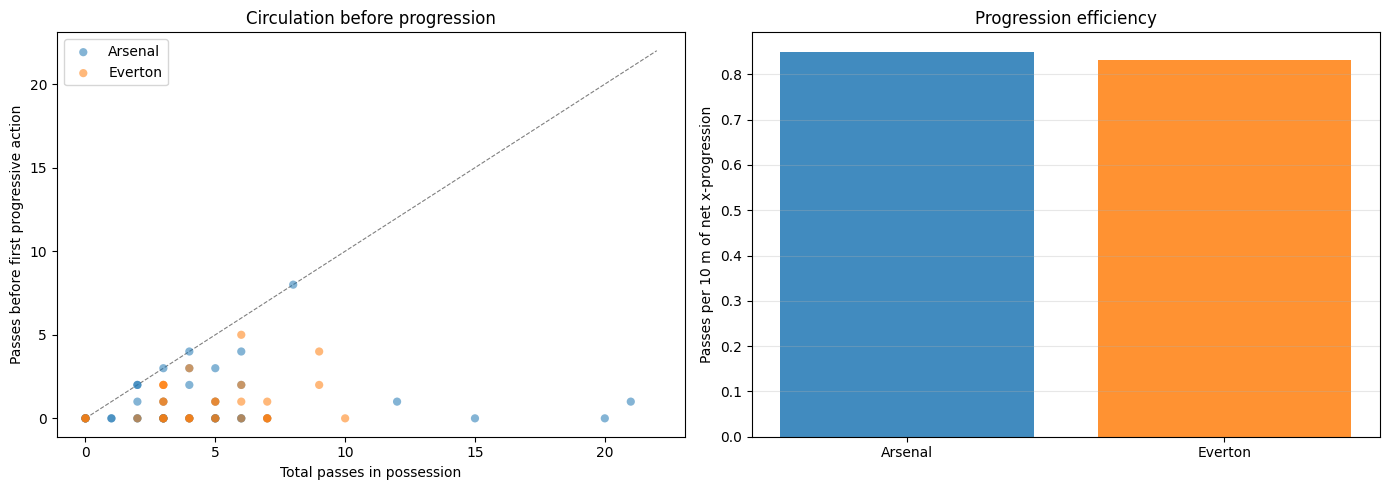

Median circulation and progression metrics (Regular Play):


,pass_count,pre_prog_pass_count,pre_prog_pass_share,pre_prog_duration_sec,progressive_action_count,avg_progressive_x_gain,passes_per_10m
possession_team,,,,,,,
Arsenal,4.0,0.0,0.00,2.0,1.0,20.90,0.85
Everton,4.0,0.0,0.07,2.0,2.0,23.72,0.83


In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_circulation_vs_progression(rhythm_summary, TEAMS, ax=axes[0])
plot_progression_efficiency(rhythm_summary, TEAMS, ax=axes[1])
plt.tight_layout()
plt.show()

# Detailed circulation table
circ_cols = [
    "possession_team",
    "pass_count",
    "pre_prog_pass_count",
    "pre_prog_pass_share",
    "pre_prog_duration_sec",
    "progressive_action_count",
    "avg_progressive_x_gain",
    "passes_per_10m",
]
available_circ = [c for c in circ_cols if c in rhythm_summary.columns]
circ_table = (
    rhythm_summary[available_circ]
    .groupby("possession_team")
    .median()
    .round(2)
)
print("Median circulation and progression metrics (Regular Play):")
display(circ_table)

<hr>

### Rhythm takeaways

- Both teams share an identical median inter-event gap of 1.0 second, so neither side is categorically quicker at the chain level. The real difference lies in distribution rather than the median: Arsenal's wider spread means they produce more possessions at both the very fast and very slow extremes, while Everton cluster more tightly around that 1-second mark.
- Everton, with a gap CV of 1.03 against Arsenal's 1.17. Everton's lower coefficient of variation indicates their tempo shifts less within a possession — the pace of successive actions stays relatively stable. Arsenal's higher CV reflects deliberate gear-changing: they slow to hold and probe, then accelerate through rapid exchanges, producing a less predictable but more dynamic rhythm.
- The intra-possession profile shows Arsenal beginning with a noticeably longer first gap before tightening quickly — a controlled, considered start that accelerates once structure is established. Everton's profile is comparatively flat across event positions, consistent with their more uniform, carry-driven tempo throughout.
- Across all Regular Play possessions, both sides record a median of zero pre-progression passes, meaning the first action in most chains is already a progressive one. The gap opens up among sustained possessions of four or more passes, where Arsenal averages 1.45 passes before their first significant forward move versus Everton's 1.05 — reflecting Arsenal's greater patience in feeling out the defensive structure before committing.
- The values are nearly identical — Arsenal 0.85 passes per 10m, Everton 0.83 — which initially   look isnot in pass efficiency but in which   posston's direct approach means fewer possessions advance, but those that do covArsenal's circulatory style produces more sustained chains overall, even if eacall a shorter distance forward.

<hr>

In [20]:
# Notebook state is rebuilt from data and project modules; no dill session needed.
dill.dump_session('../saves/notebook_env.db')